In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
import joblib

ЭТАП 1: Анализ данных (EDA) Общая загрузка

In [2]:
# 1.Загрузить train.csv, вывести 10 строк.
df = pd.read_csv('loan_data.csv')
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [3]:
# 2.Посмотреть .info() и .shape.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [4]:
df.shape

(45000, 14)

In [5]:
# 3.Проверить уникальные по object-признакам.
df.select_dtypes(include='object').nunique()

,0
person_gender,2
person_education,5
person_home_ownership,4
loan_intent,6
previous_loan_defaults_on_file,2


In [6]:
object_typea_vaiues = ['person_gender', 'person_education','person_home_ownership',
                       'loan_intent', 'previous_loan_defaults_on_file']
for i in object_typea_vaiues:
 print(f'{i}:{df[i].unique()}')

person_gender:['female' 'male']
person_education:['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
person_home_ownership:['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent:['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
previous_loan_defaults_on_file:['No' 'Yes']


In [7]:
#4.Оставить только выбранные 7 признаков + целевую переменную.
new_df = df[['person_age', 'person_income', 'person_emp_exp', 'person_home_ownership',
         'loan_amnt', 'loan_int_rate', 'credit_score', 'loan_status']]


In [8]:
#5.Сохранить облегчённый датасет в loan_clean.csv.
df.to_csv('loan_clean.csv', index=False)


Homework: Pandas-практика

In [9]:
#6.Посчитать средний доход, возраст, стаж.
df[['person_income', 'person_age', 'person_emp_exp']].mean().round(2)

,0
person_income,80319.05
person_age,27.76
person_emp_exp,5.41


In [10]:
#7.Сколько заемщиков имеют кредитный балл < 600?
(df['credit_score'] < 600).sum()

np.int64(10828)

In [11]:
#8.Распределение по типу жилья (person_home_ownership) — value_counts().
df['person_home_ownership'].value_counts(normalize=True).round(2)

,proportion
person_home_ownership,
RENT,0.52
MORTGAGE,0.41
OWN,0.07
OTHER,0.00


In [12]:
#9.Средняя ставка и сумма кредита по группам loan_status.
df.groupby('loan_status')[['loan_int_rate','loan_amnt']].mean().round(2)

,loan_int_rate,loan_amnt
loan_status,,
0,10.48,9219.58
1,12.86,10855.69


In [13]:
#10.Кол-во заявителей с опытом работы 0 лет.
(df['person_emp_exp'] == 0).sum()

np.int64(9566)

In [14]:
#11. Сколько заемщиков берут кредит более чем на половину дохода
(df['person_income'] > 0.5).sum()

np.int64(45000)

In [15]:
#12.Группировка по person_home_ownership — средний loan_int_rate.
df.groupby('person_home_ownership')['loan_int_rate'].mean().round(2)

,loan_int_rate
person_home_ownership,
MORTGAGE,10.56
OTHER,12.03
OWN,10.83
RENT,11.38


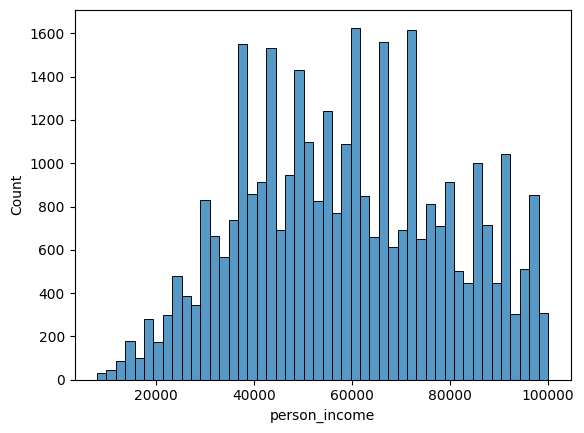

In [16]:
#13.Hist / distplot по:
#o	person_income
#o	credit_score
#o	loan_int_rate
sns.histplot(data=df[df['person_income'] < 100000], x='person_income')
plt.show()

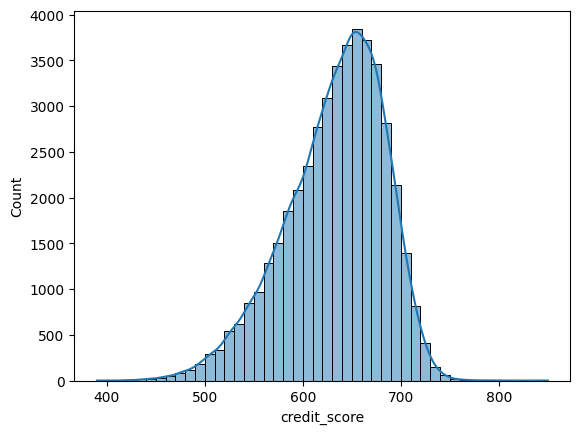

In [17]:
sns.histplot(data=df, x='credit_score', binwidth=10, kde=True)
plt.show()

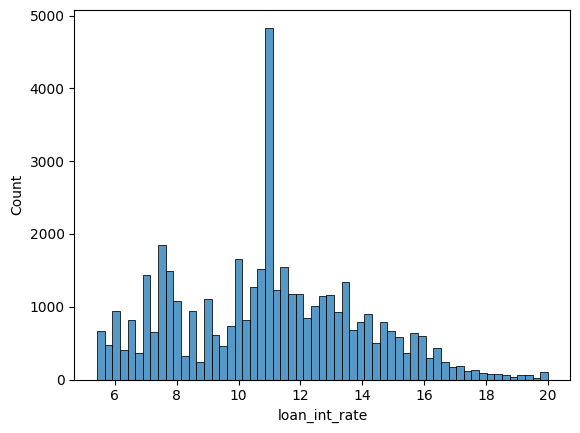

In [18]:
sns.histplot(data=df, x='loan_int_rate')
plt.show()

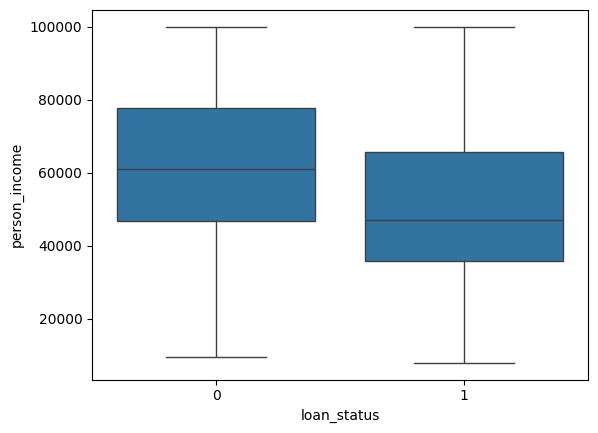

In [19]:
#14.Boxplot: loan_status vs person_income
sns.boxplot(data=df[df['person_income'] < 100000], x='loan_status', y='person_income')
plt.show()

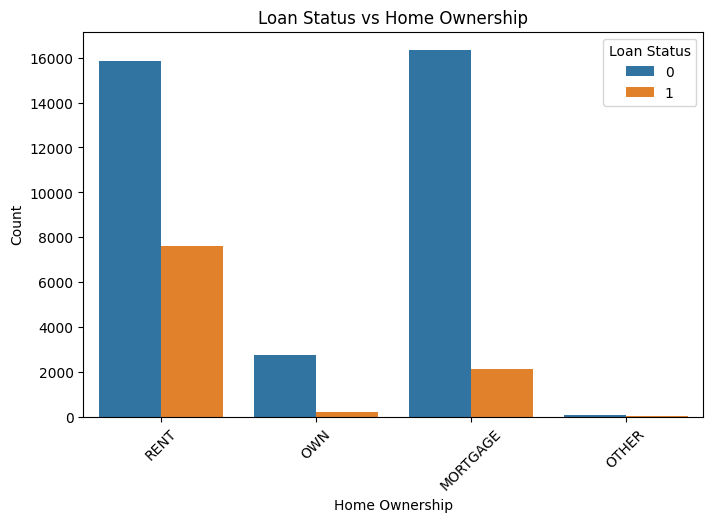

In [20]:
#15.Barplot: loan_status vs person_home_ownership
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='person_home_ownership', hue='loan_status')
plt.title('Loan Status vs Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Loan Status')
plt.show()

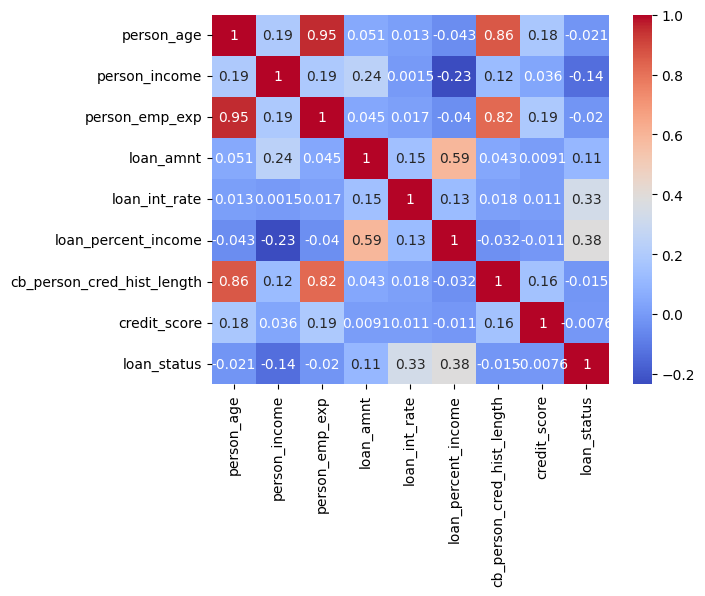

In [21]:
#16.Heatmap корреляций числовых признаков
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

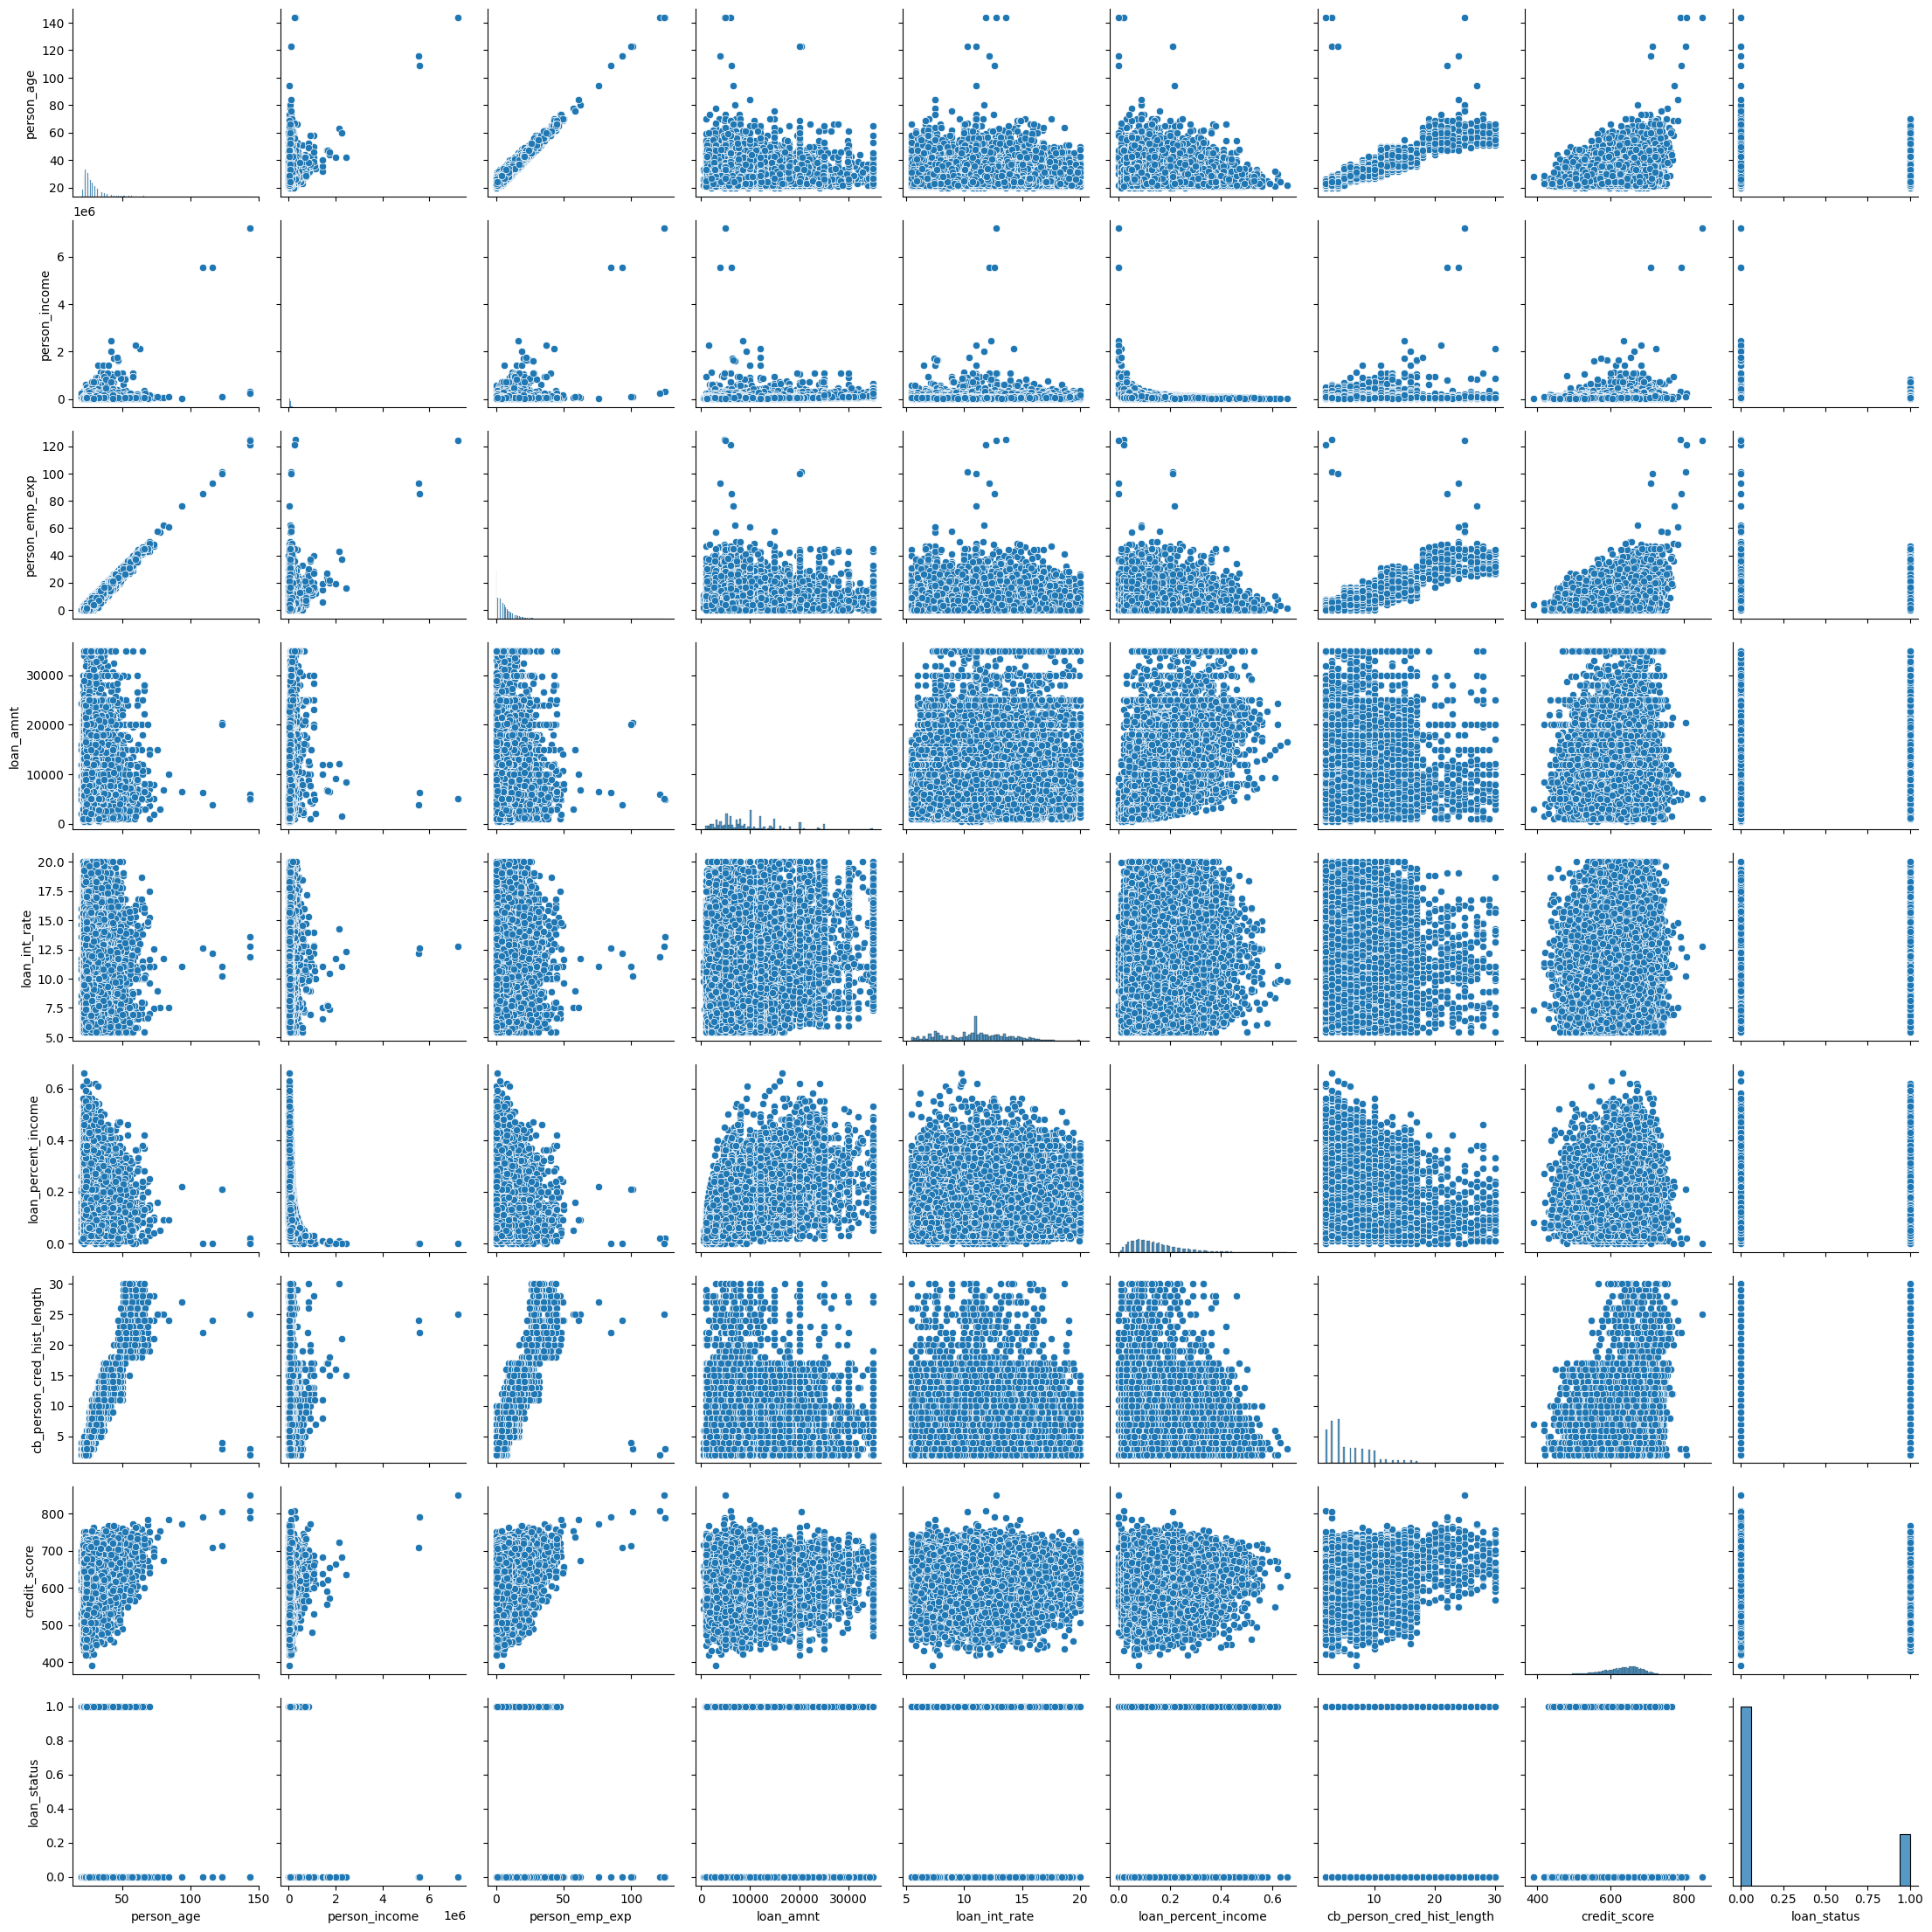

In [22]:
#17.Pairplot по числовым признакам
sns.pairplot(df)
plt.show()

ЭТАП 2: Предобработка

In [23]:
#18.Проверка пропущенных значений и заполнение (или удаление).
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [24]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [25]:
#19.	Кодировка категориальных признаков (OneHotEncoder или LabelEncoder):
#o	person_home_ownership
df = pd.get_dummies(df, columns=['person_gender', 'person_education','person_home_ownership',
                       'loan_intent', 'previous_loan_defaults_on_file'], drop_first=True).astype(int)


In [26]:
df

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_male,...,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,22,71948,0,35000,16,0,3,561,1,0,...,1,0,0,1,0,0,0,1,0,0
1,21,12282,0,1000,11,0,2,504,0,0,...,0,0,1,0,1,0,0,0,0,1
2,25,12438,3,5500,12,0,3,635,1,0,...,0,0,0,0,0,0,1,0,0,0
3,23,79753,0,35000,15,0,2,675,1,0,...,0,0,0,1,0,0,1,0,0,0
4,24,66135,1,35000,14,0,4,586,1,1,...,1,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,47971,6,15000,15,0,3,645,1,1,...,0,0,0,1,0,0,1,0,0,0
44996,37,65800,17,9000,14,0,11,621,1,0,...,0,0,0,1,0,1,0,0,0,0
44997,33,56942,7,2771,10,0,10,668,1,1,...,0,0,0,1,0,0,0,0,0,0
44998,29,33164,4,12000,13,0,6,604,1,1,...,0,0,0,1,1,0,0,0,0,0


In [27]:
#20.Масштабирование числовых признаков (StandardScaler).
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop(columns='loan_status'))


In [28]:
scaled_data

array([[-0.95353824, -0.10408961, -0.89228413, ...,  2.22681082,
        -0.45857996, -1.01603973],
       [-1.11896309, -0.84600467, -0.89228413, ..., -0.44907272,
        -0.45857996,  0.98421348],
       [-0.45726369, -0.84406489, -0.3975175 , ..., -0.44907272,
        -0.45857996, -1.01603973],
       ...,
       [ 0.8661351 , -0.29068126,  0.26217134, ..., -0.44907272,
        -0.45857996, -1.01603973],
       [ 0.2044357 , -0.58634807, -0.23259529, ..., -0.44907272,
        -0.45857996, -1.01603973],
       [-0.62268854, -0.35699428, -0.72736192, ..., -0.44907272,
        -0.45857996, -1.01603973]])

In [29]:
df.drop(columns='loan_status').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   person_age                          45000 non-null  int64
 1   person_income                       45000 non-null  int64
 2   person_emp_exp                      45000 non-null  int64
 3   loan_amnt                           45000 non-null  int64
 4   loan_int_rate                       45000 non-null  int64
 5   loan_percent_income                 45000 non-null  int64
 6   cb_person_cred_hist_length          45000 non-null  int64
 7   credit_score                        45000 non-null  int64
 8   person_gender_male                  45000 non-null  int64
 9   person_education_Bachelor           45000 non-null  int64
 10  person_education_Doctorate          45000 non-null  int64
 11  person_education_High School        45000 non-null  int64
 12  pers

In [30]:
#21.Разделение X и y (где y = loan_status).
x= scaled_data
y=df['loan_status']

In [31]:
#22.train/test split (80/20).
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

ЭТАП 3: Логистическая регрессия

In [32]:
#23.Обучить LogisticRegression() на обучающей выборке.
log_model = LogisticRegression()
log_model.fit(x_train, y_train)

LogisticRegression()

In [33]:
#24.Предсказать на тестовой выборке.
pred = log_model.predict(x_test)

In [34]:
# 25.Посчитать метрики:
# Accuracy
# Precision, Recall
# F1-score
# Confusion Matrix (график)
# ROC AUC (и построить кривую)
print(accuracy_score(pred, y_test))
print(f1_score(pred, y_test))

0.8836666666666667
0.7381845461365342


In [35]:
#26.Вывести коэффициенты модели (model.coef_, model.intercept_)
log_model.coef_

array([[ 1.04559396e-01, -1.85772484e+00, -1.13408017e-01,
         6.36961454e-01,  8.73182580e-01,  0.00000000e+00,
         5.12083203e-03, -4.43991160e-01,  1.25732507e-02,
        -9.90781273e-03,  2.54722741e-03, -3.31397796e-03,
        -4.86818274e-03,  3.19829095e-02, -2.32931284e-01,
         4.27237388e-01, -3.11102053e-01, -8.05021043e-03,
        -9.44199317e-02, -2.37929276e-01, -4.03700965e-01,
        -4.47997485e+00]])

In [36]:
#27.Сохранить модель (joblib или pickle).
joblib.dump(log_model, 'log_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']